In [22]:
import matplotlib.pyplot as plt
from msca import *
import os
import importlib
import msca
import msca.models
import msca.architectures
import msca.utils
import msca.simulations
# Suppress MallocStackLogging warnings on macOS
os.environ["MallocStackLogging"] = "0"

# Reload msca and key submodules after code changes
importlib.reload(msca.architectures)
importlib.reload(msca.models)
importlib.reload(msca.utils)
importlib.reload(msca)
importlib.reload(msca.simulations)


# Re-import updated symbols
from msca import *

In [23]:
import importlib
import os
import numpy as np
from scipy import io
from pathlib import Path



_HERE = Path(".").resolve()  # or Path(__file__).resolve().parent in a .py file
_CYCLING_DATA_DIR = _HERE / "data"

def load_data(dir_path, f):
    mat_file = io.loadmat(dir_path + f)
    data_array = mat_file["data"]
    mask = mat_file["mask"]
    start_idxs = mask["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs   = mask["lastTimeEachCond"][0][0].squeeze()
    num_cycles = int(np.nanmax(mask["cycleNum"][0][0]))

    # Per-trial direction and position (value at the first timepoint of each trial)
    dir_raw = mask["dir"][0][0].squeeze()
    pos_raw = mask["pos"][0][0].squeeze()
    direction = np.array([dir_raw[i] for i in start_idxs])
    position  = np.array([pos_raw[i] for i in start_idxs])
    return data_array, mask, start_idxs, end_idxs, num_cycles, direction, position

# Preprocess the loaded data and split into trials
def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    """
    Pre-processing done by Andrew Zimnik
    """
    # Downsample the data
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]

        # Adjust the start and end indices to account for the downsampling
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    # Transpose the data to N x TC
    data_concat = data_downsamp.T

    # fr range (for normalizing later)
    fr_range = np.ptp(data_concat, axis=1)[:, None]

    # Soft normalize (divide each neuron by its range + 5)
    data_norm = data_concat / (fr_range + 5)

    # mean-center each neuron
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]

    # rename the data for convenience
    # Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
    fit_data = np.copy(data_snm_norm.T)

    # Split the data into trials
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]

    return split_data




fp = "./data/"
m1_data, m1_mask, m1_start_idxs, m1_end_idxs, m1_num_cycles, m1_direction, m1_position = load_data(
    f"{fp}", "Drake_interp_cycling_m1_rawRates.mat"
)
sma_data, sma_mask, sma_start_idxs, sma_end_idxs, sma_num_cycles, sma_direction, sma_position = load_data(
    f"{fp}", "Drake_interp_cycling_sma_rawRates.mat"
)

# Preprocess the data
m1_preprocessed = preprocess(
    m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5
)
sma_preprocessed = preprocess(
    sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5
)

# Put data into dictionary format
X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}


In [24]:
from matplotlib.lines import Line2D
# --- Condition -> visual encoding (edit to match your .mat's values) ---------
# Direction value treated as "forwards" (RED); the other value -> backwards
# (GREEN). cycling.py used direction in {1, -1}.
FORWARD_VALUE = 1
# start_pos (position) value drawn SOLID; the other value -> dotted. The user's
# convention is start_pos=-1 -> solid, +1 -> dotted. cycling.py used {0.0, 0.5},
# in which case the lower value is drawn solid (see _build_encoders fallback).
# SOLID_STARTPOS = -1
SOLID_STARTPOS = 0.0

# Base hue per region (saturated for high inter-region contrast). Regions not
# listed fall back to the _FALLBACK_HUES cycle (by region rank).
_REGION_HUE = {
    "M1": np.array([0.90, 0.0, 0.0]),  # red
    "SMA": np.array([0.0, 0.65, 0.0]),  # green
}
_FALLBACK_HUES = [
    np.array([0.0, 0.0, 0.90]),  # blue
    np.array([0.60, 0.40, 0.0]),  # amber
    np.array([0.55, 0.0, 0.70]),  # purple
]

# Direction shade: forward darkened toward black, backward lightened toward
# white. Bigger values -> more separation between forward/backward.
_FORWARD_DARKEN = 0.45  # forward: brightness *= (1 - this)
_BACKWARD_LIGHTEN = 0.55  # backward: blend toward white by this

# Line styling (thicker + less transparent for visibility).
_LINE_ALPHA = 0.75
_LINE_WIDTH = 1.1


def _region_hue(region: str, rank: int) -> np.ndarray:
    """Base hue for a region (named map first, then a fallback cycle by rank)."""
    if region in _REGION_HUE:
        return _REGION_HUE[region]
    return _FALLBACK_HUES[rank % len(_FALLBACK_HUES)]


def _shade_by_direction(rgb: np.ndarray, is_forward: bool) -> tuple:
    """Forward -> darker (toward black); backward -> lighter (toward white)."""
    rgb = np.asarray(rgb, dtype=float)
    if is_forward:
        return tuple(rgb * (1.0 - _FORWARD_DARKEN))
    return tuple(rgb + (1.0 - rgb) * _BACKWARD_LIGHTEN)


def load_conditions(dataset_spec: dict) -> tuple[np.ndarray, np.ndarray]:
    """
    Re-read per-trial (direction, position) from the cycling .mat mask. Uses the
    first region's file (conditions are shared across regions) and returns arrays
    aligned to the trial order the loader produces.
    """
    if dataset_spec.get("loader") != "cycling":
        raise ValueError(
            "plot_all_region_specific_latents only supports cycling datasets; "
            f"got loader={dataset_spec.get('loader')!r}."
        )
    files = dataset_spec["files"]
    _region0, fname = next(iter(files.items()))

    data_dir = _CYCLING_DATA_DIR
    if "data_dir" in dataset_spec:
        p = Path(dataset_spec["data_dir"])
        data_dir = p if p.is_absolute() else (_HERE / p).resolve()

    # load_data -> (data, mask, start_idxs, end_idxs, num_cycles, direction, position)
    _d, _m, _si, _ei, _nc, direction, position = load_data(f"{data_dir}/", fname)
    return np.asarray(direction).squeeze(), np.asarray(position).squeeze()


def _build_encoders(direction: np.ndarray, position: np.ndarray):
    """
    Build per-trial encoders from the values actually present:
      hue_key(d)   -> "forward"/"backward"
      linestyle(p) -> "-"/":"
    Falls back to value ordering if the configured constants aren't present
    (forward = larger direction value; solid = smaller start_pos value).
    """
    dir_vals = sorted({float(x) for x in np.ravel(direction)})
    fwd = float(FORWARD_VALUE) if float(FORWARD_VALUE) in dir_vals else max(dir_vals)

    pos_vals = sorted({float(x) for x in np.ravel(position)})
    solid = (
        float(SOLID_STARTPOS) if float(SOLID_STARTPOS) in pos_vals else min(pos_vals)
    )

    def hue_key(d):
        return "forward" if float(d) == fwd else "backward"

    def linestyle(p):
        return "-" if float(p) == solid else ":"

    return hue_key, linestyle, fwd, solid

def plot_cell(latents: dict, direction, position, title: str = ""):
    regions = list(latents.keys())
    K = latents[regions[0]][0].shape[1]
    n_trials = len(latents[regions[0]])
    if len(direction) != n_trials or len(position) != n_trials:
        raise ValueError(
            f"condition length mismatch: {len(direction)} direction / "
            f"{len(position)} position vs {n_trials} trials"
        )

    hue_key, linestyle, fwd, solid = _build_encoders(direction, position)

    # Region -> base hue (M1 red, SMA green); direction sets the shade.
    region_hue = {r: _region_hue(r, i) for i, r in enumerate(regions)}

    n_cols = 10
    n_rows = max(1, int(np.ceil(K / n_cols)))
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2 * n_cols, 1.2 * n_rows), squeeze=False
    )
    axes_flat = axes.flatten()

    for k in range(K):
        ax = axes_flat[k]
        for r in regions:
            for t, trial in enumerate(latents[r]):
                is_fwd = hue_key(direction[t]) == "forward"
                color = _shade_by_direction(region_hue[r], is_fwd)
                ax.plot(
                    trial[:, k],
                    color=color,
                    ls=linestyle(position[t]),
                    alpha=_LINE_ALPHA - 0.1,
                    lw=_LINE_WIDTH,
                )
        ax.set_title(f"comp {k}", fontsize=7)
        ax.tick_params(labelsize=5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for k in range(K, len(axes_flat)):  # hide unused panels
        axes_flat[k].set_visible(False)

    # Legend: region hue, direction shade, start_pos linestyle.
    handles = [Line2D([0], [0], color=region_hue[r], lw=3, label=r) for r in regions]
    _ref = region_hue[regions[0]]  # reference hue for the direction-shade swatches
    handles += [
        Line2D(
            [0],
            [0],
            color=_shade_by_direction(_ref, True),
            lw=2,
            label="forward (darker)",
        ),
        Line2D(
            [0],
            [0],
            color=_shade_by_direction(_ref, False),
            lw=2,
            label="backward (lighter)",
        ),
    ]
    handles += [
        Line2D([0], [0], color="k", ls="-", lw=2, label=f"start_pos {solid:g} (solid)"),
        Line2D([0], [0], color="k", ls=":", lw=2, label="other start_pos (dotted)"),
    ]
    fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)
    if title:
        fig.suptitle(title, fontsize=10)

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()



# Linear

In [20]:
msca = mSCA(n_components=40, n_epochs=5000, loss_func="Gaussian", lr=1e-3, filter_len=41, linear=True, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="linear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=-1)
msca.load("./results/Drake/linear-linear-sweeping_lam_orthog/msca_linear_linear_lamOrthog_0p0.pt", X)
import torch
import torch._dynamo
import numpy as np
import matplotlib.pyplot as plt

torch._dynamo.config.suppress_errors = True
dataset_spec = {
    "loader": "cycling",
    "files": {"M1": "Drake_interp_cycling_m1_rawRates.mat"},
}

Z = msca.transform(X)


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


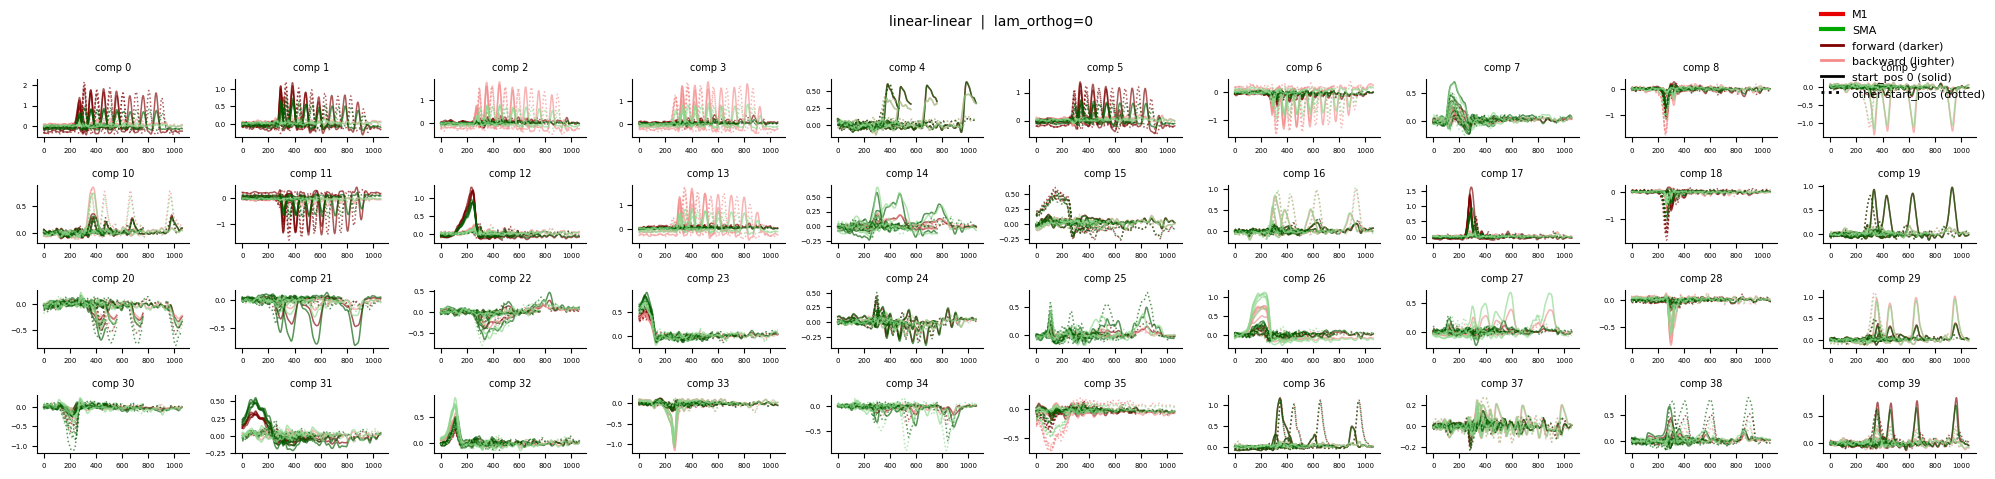

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


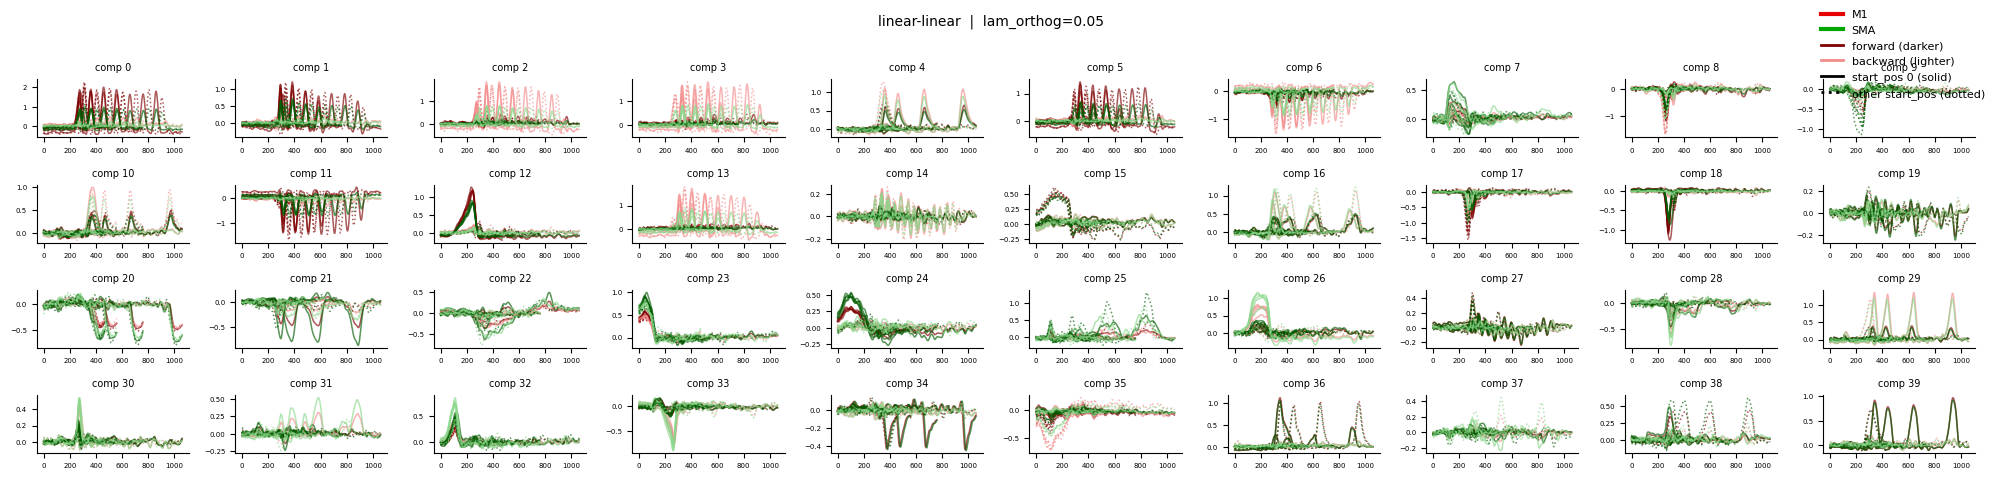

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)
[2026-06-12 11:41:25,433] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-06-12 11:41:25,433] torch._dynamo.convert_frame: [WARNING]    function: '_gaussian_filter' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:72)
[2026-06-12 11:41:25,433] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-06-12 11:41:25,433] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-06-12 11:41:25,433] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/mas

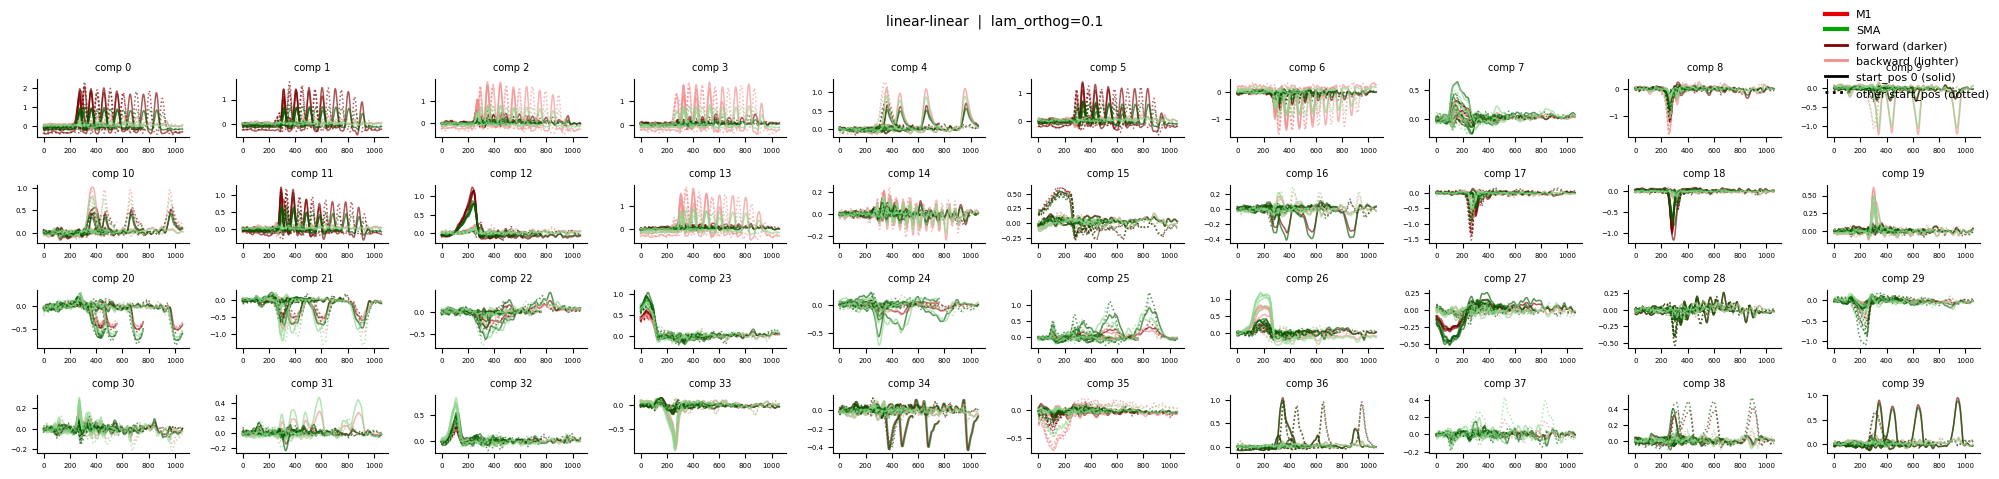

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


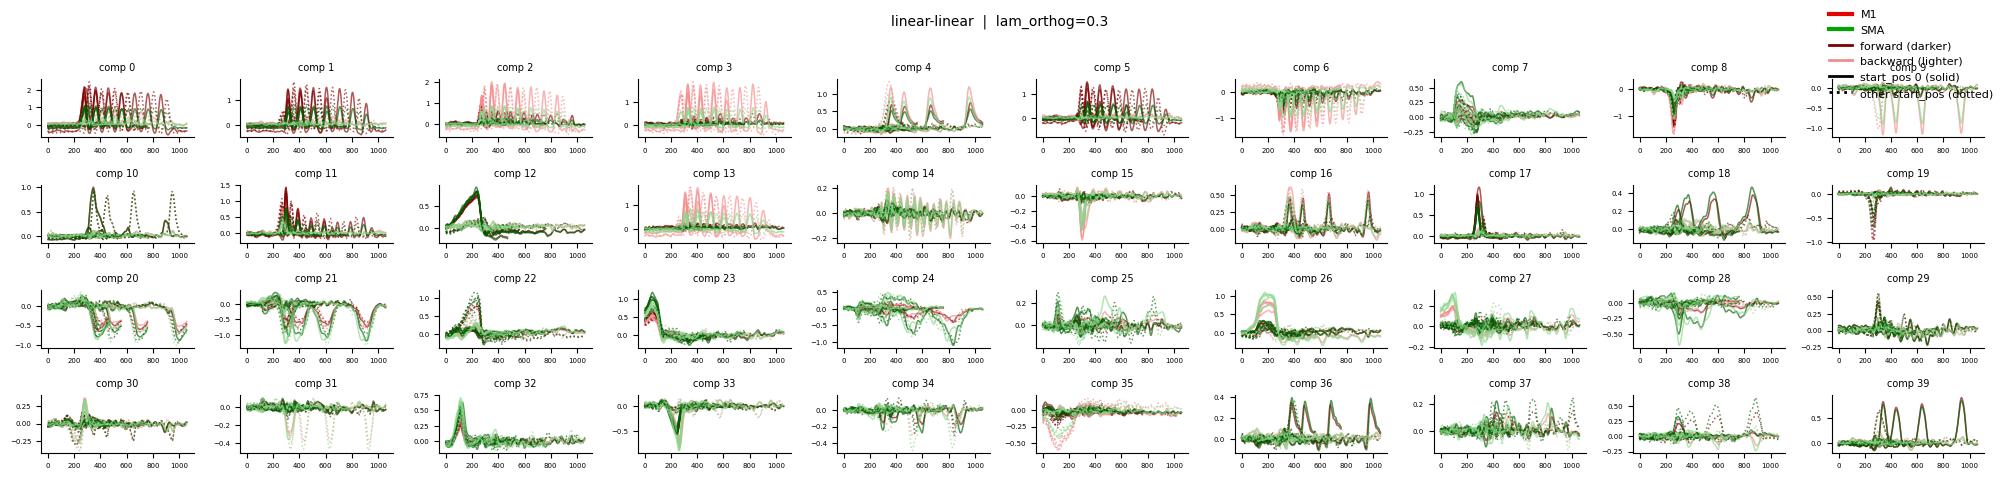

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


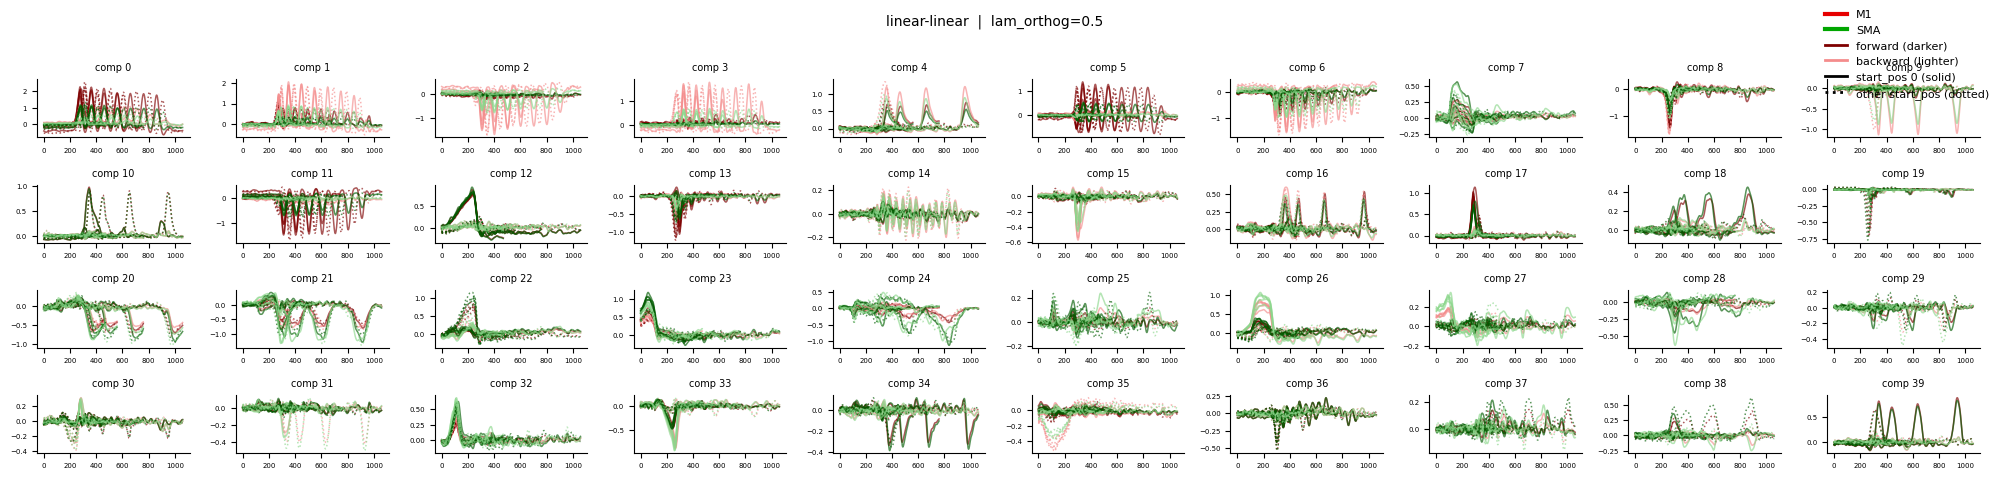

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


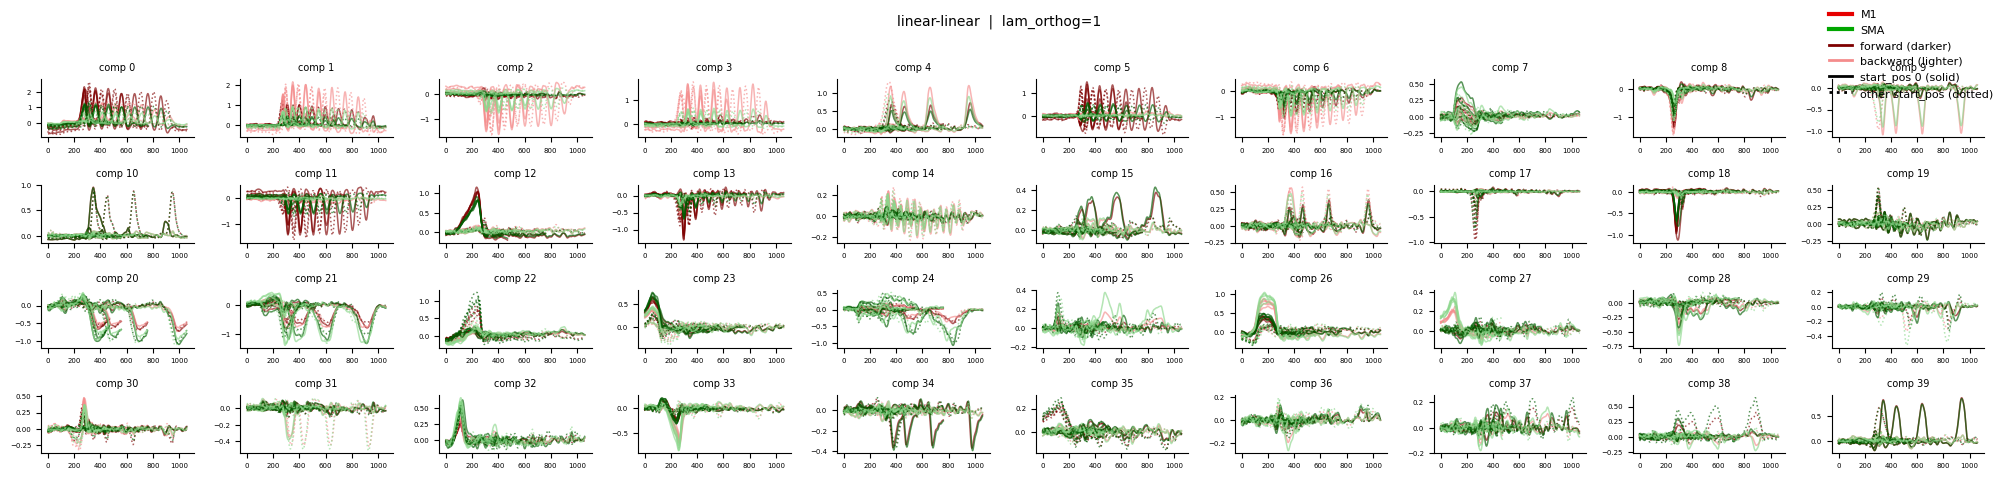

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


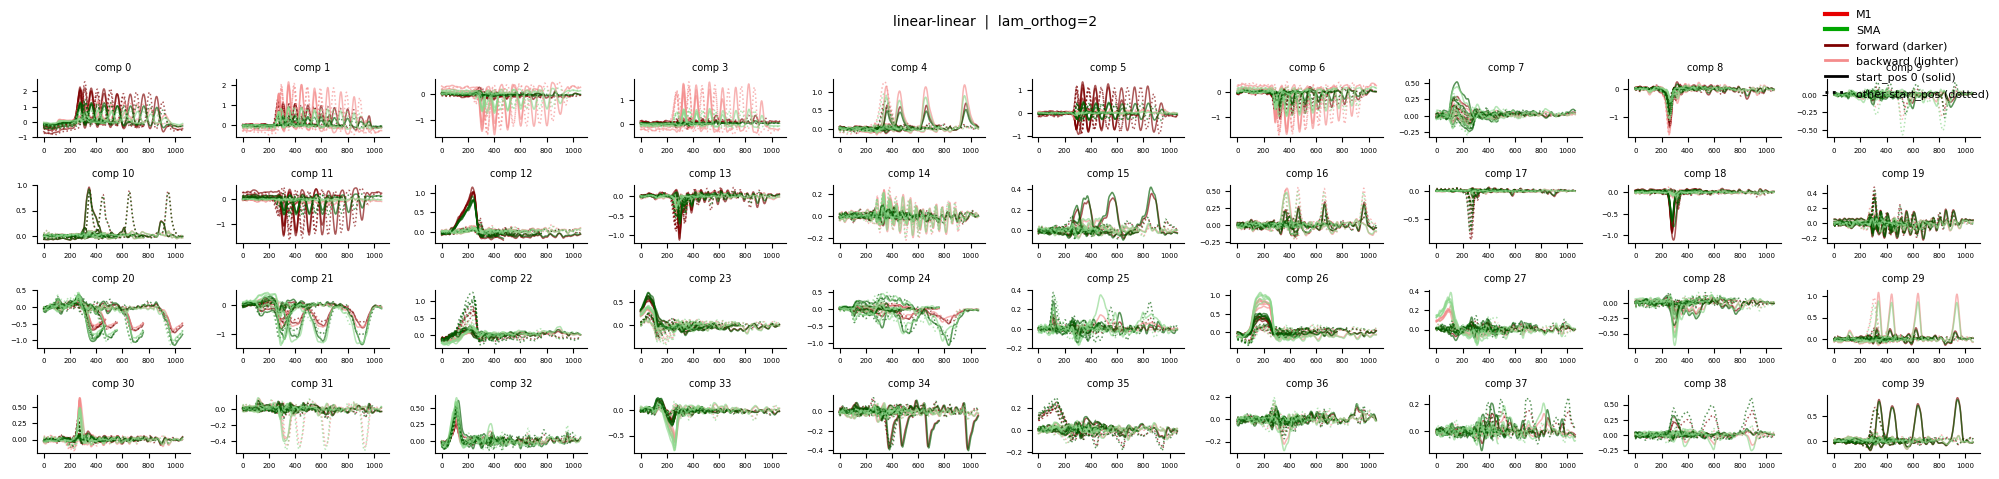

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


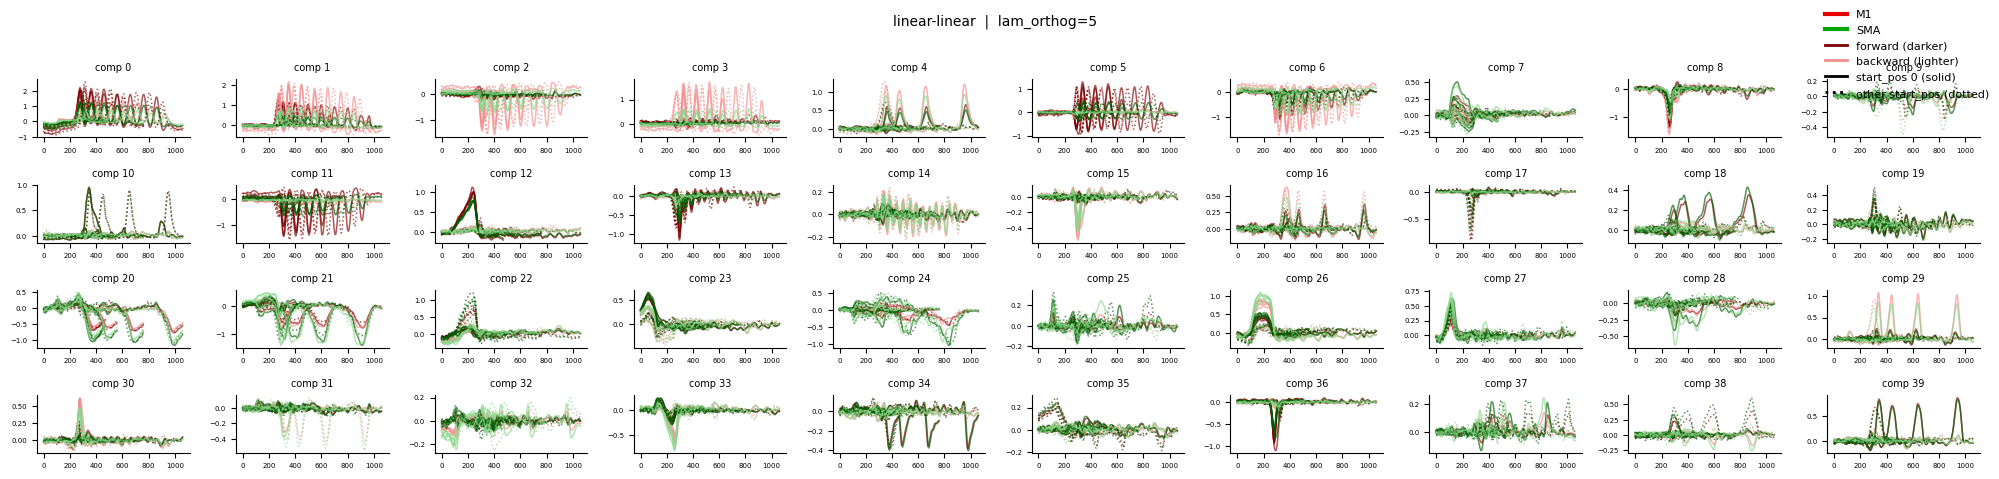

In [21]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import io
import torch
import sys
sys.path.insert(0, "../..")  # repo root so `msca` is importable
from msca import mSCA
results_dir = Path("results/Drake/linear-linear-sweeping_lam_orthog")

model_files = sorted(
    results_dir.glob("msca_linear_linear_lamOrthog_*.pt"),
    key=lambda p: float(re.search(r"lamOrthog_(.+)\.pt", p.name).group(1).replace("p", "."))
)

for model_path in model_files:
    lam_val = float(re.search(r"lamOrthog_(.+)\.pt", model_path.name).group(1).replace("p", "."))

    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    meta = checkpoint["meta"]

    msca_model = mSCA(
        n_components=meta["n_components"],
        linear=meta["linear"],
        decoder_type=meta["decoder_type"],
        decoder_hidden_size=meta["decoder_hidden_size"],
        decoder_activation=meta["decoder_activation"],
    )
    msca_model.load(str(model_path), X)
    latents = msca_model.transform(X)

    plot_cell(latents,*load_conditions(dataset_spec),title=f"linear-linear  |  lam_orthog={lam_val:g}")


# Nonlinear

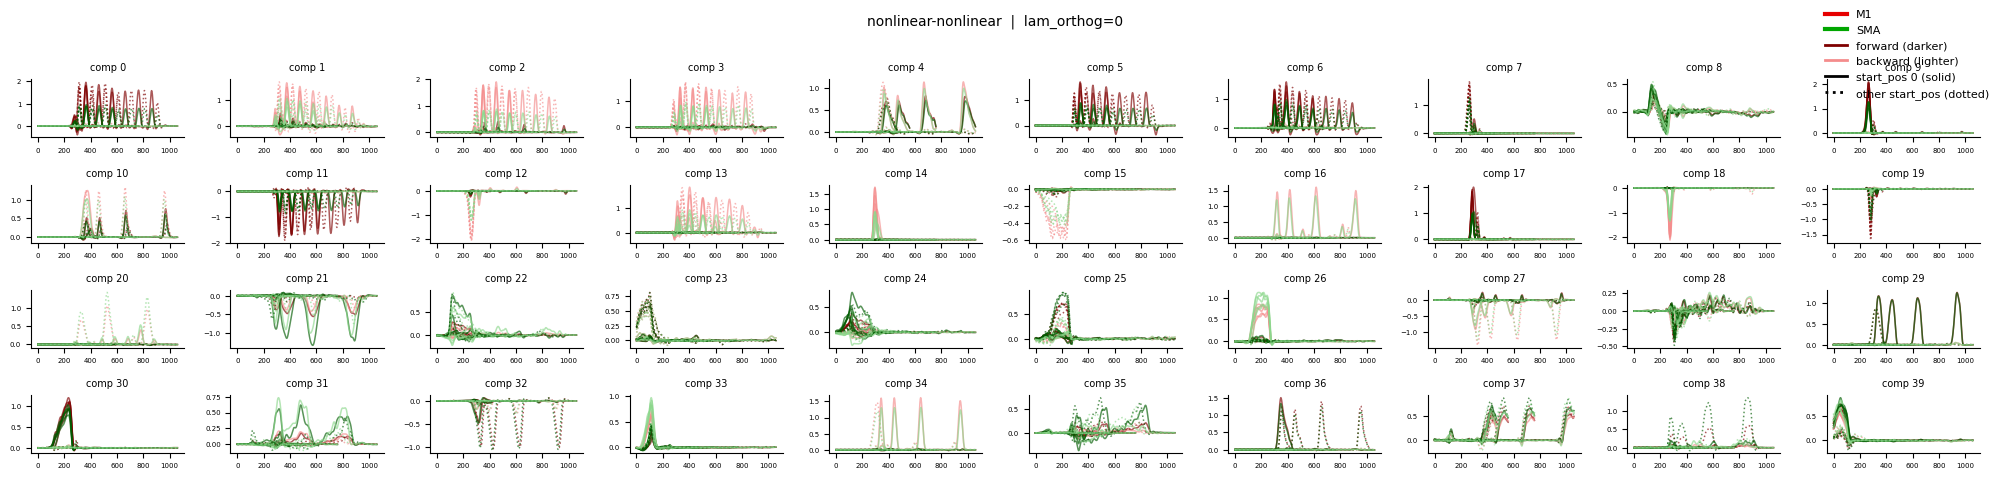

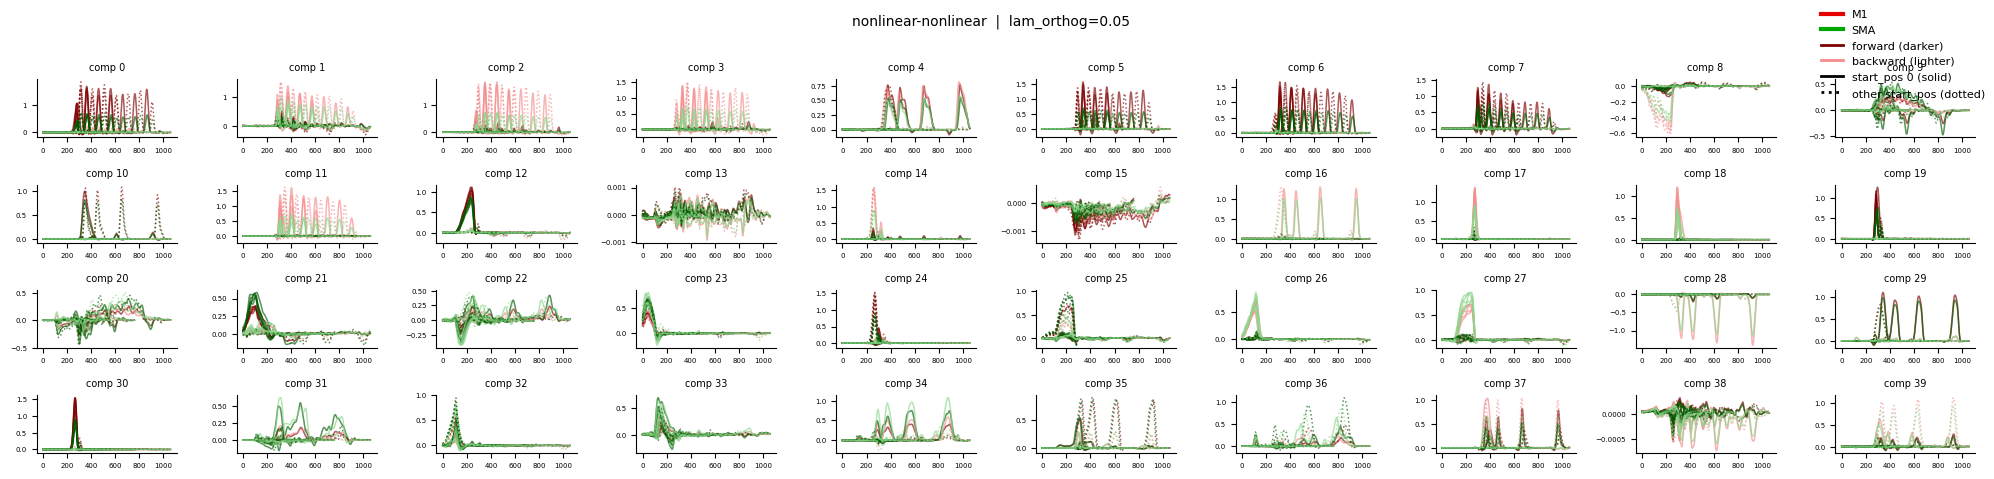

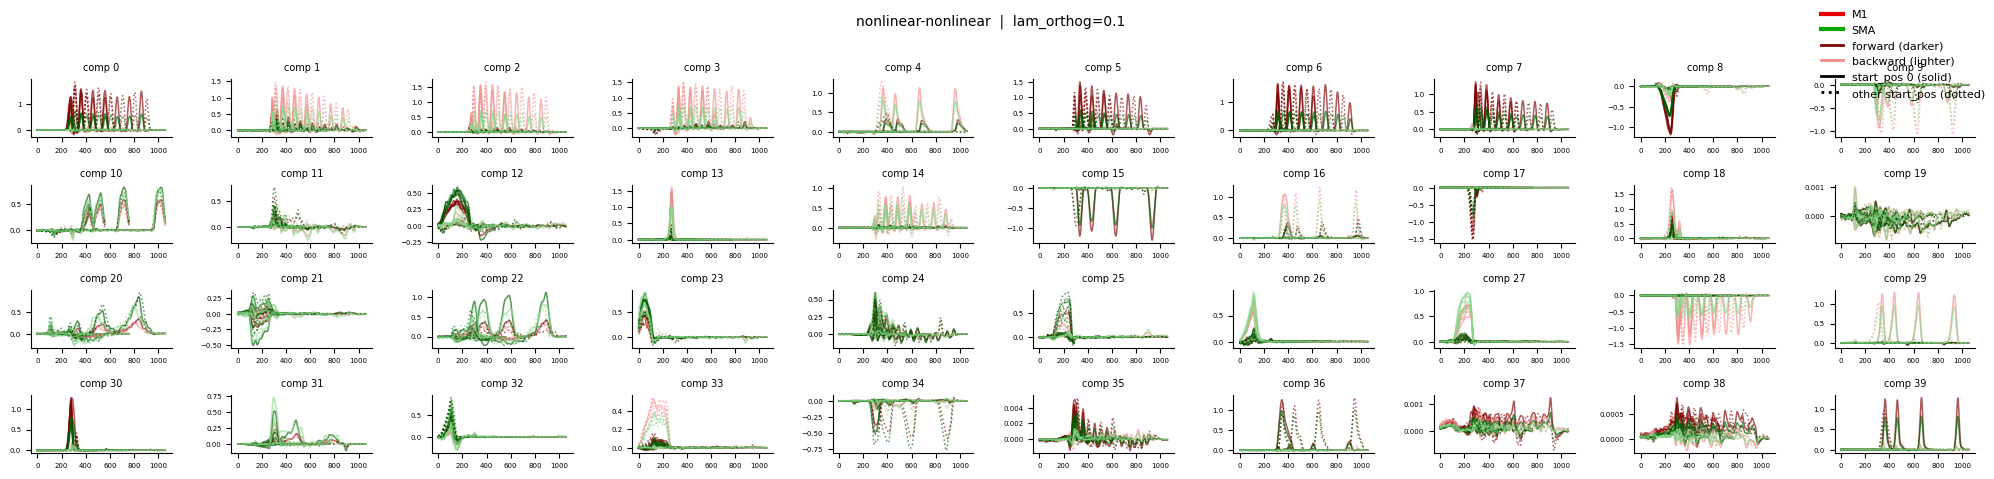

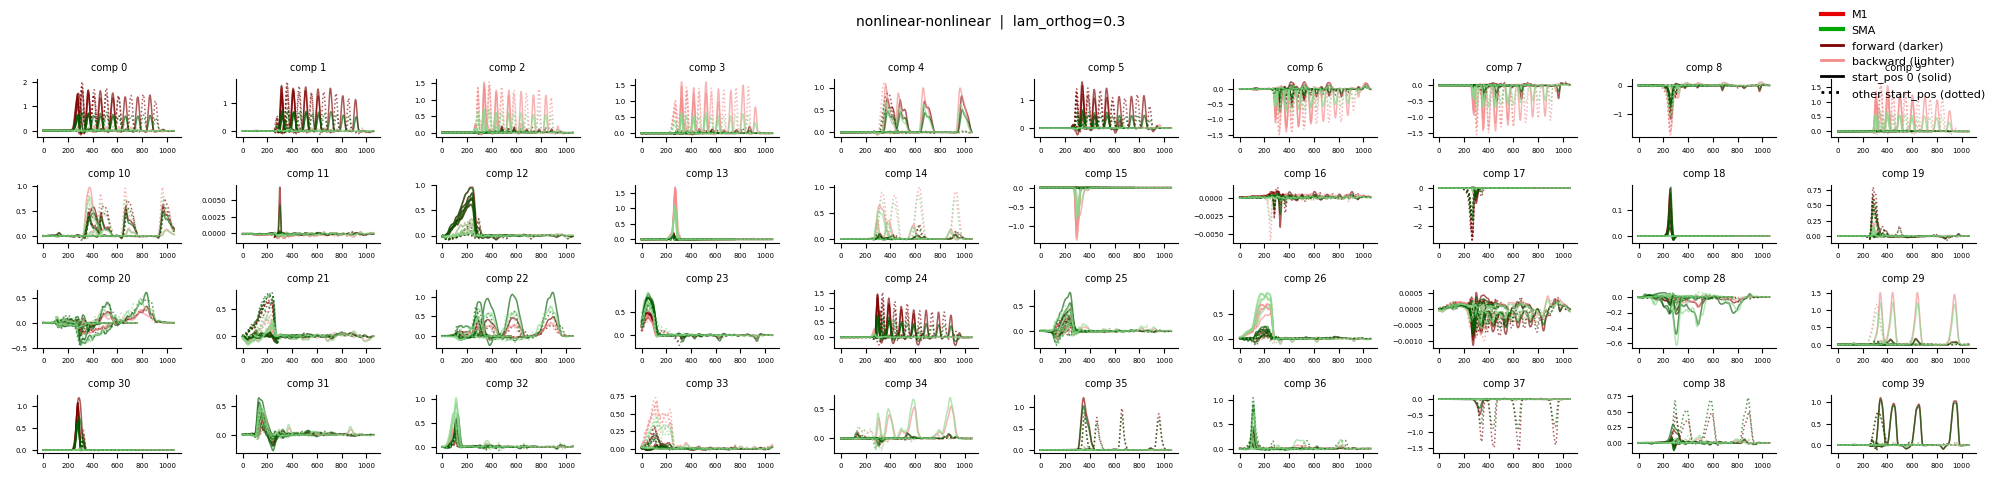

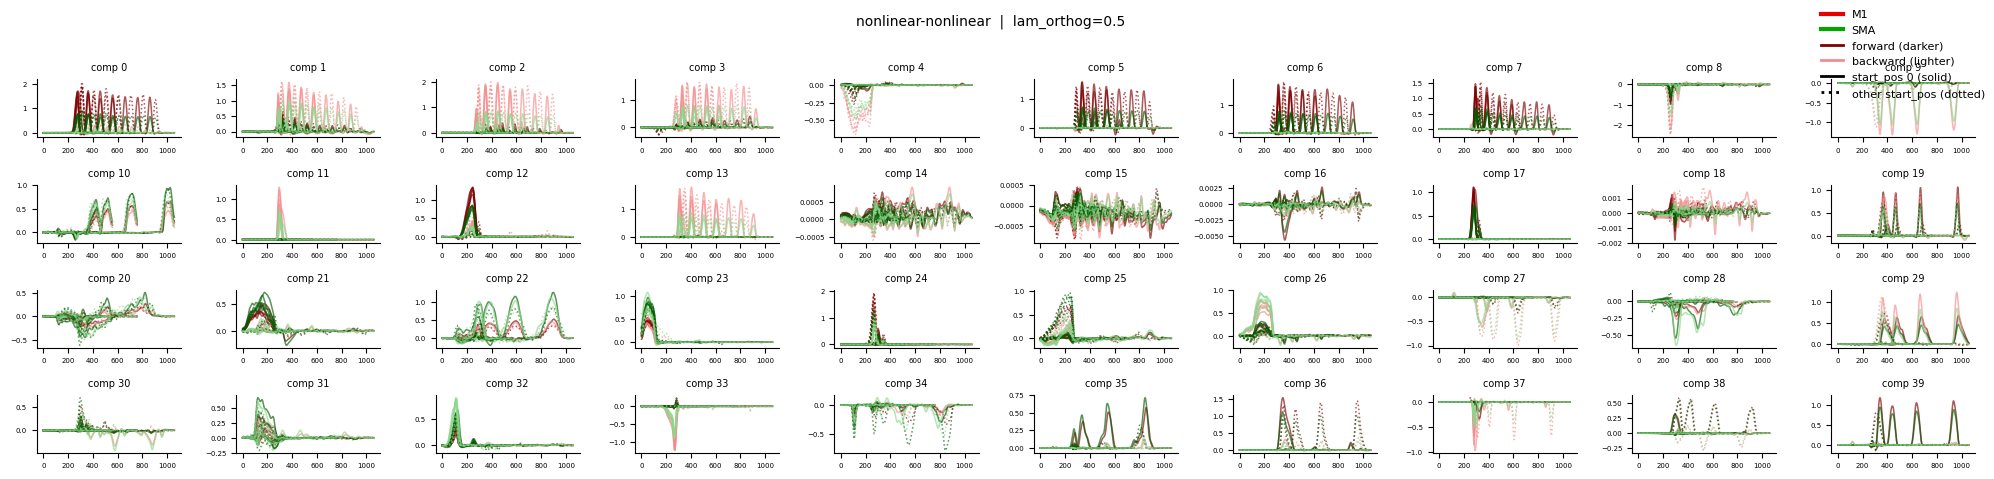

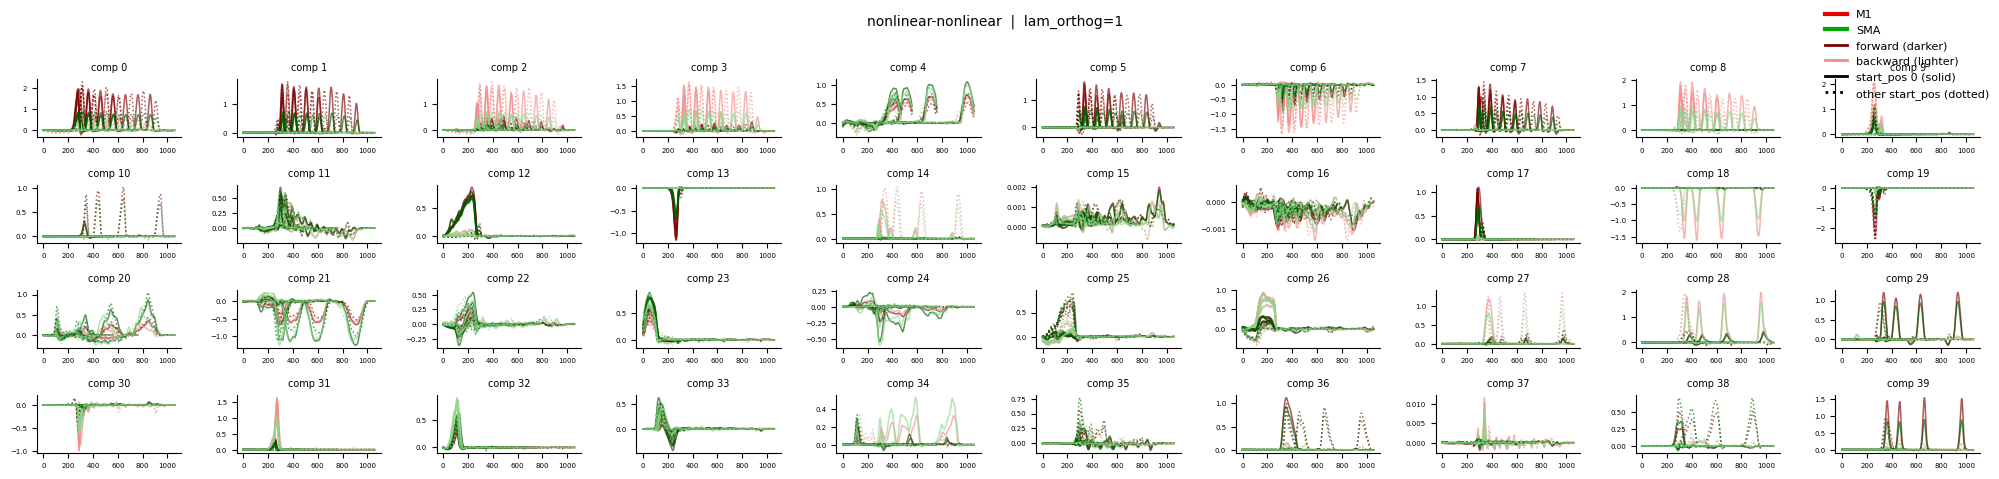

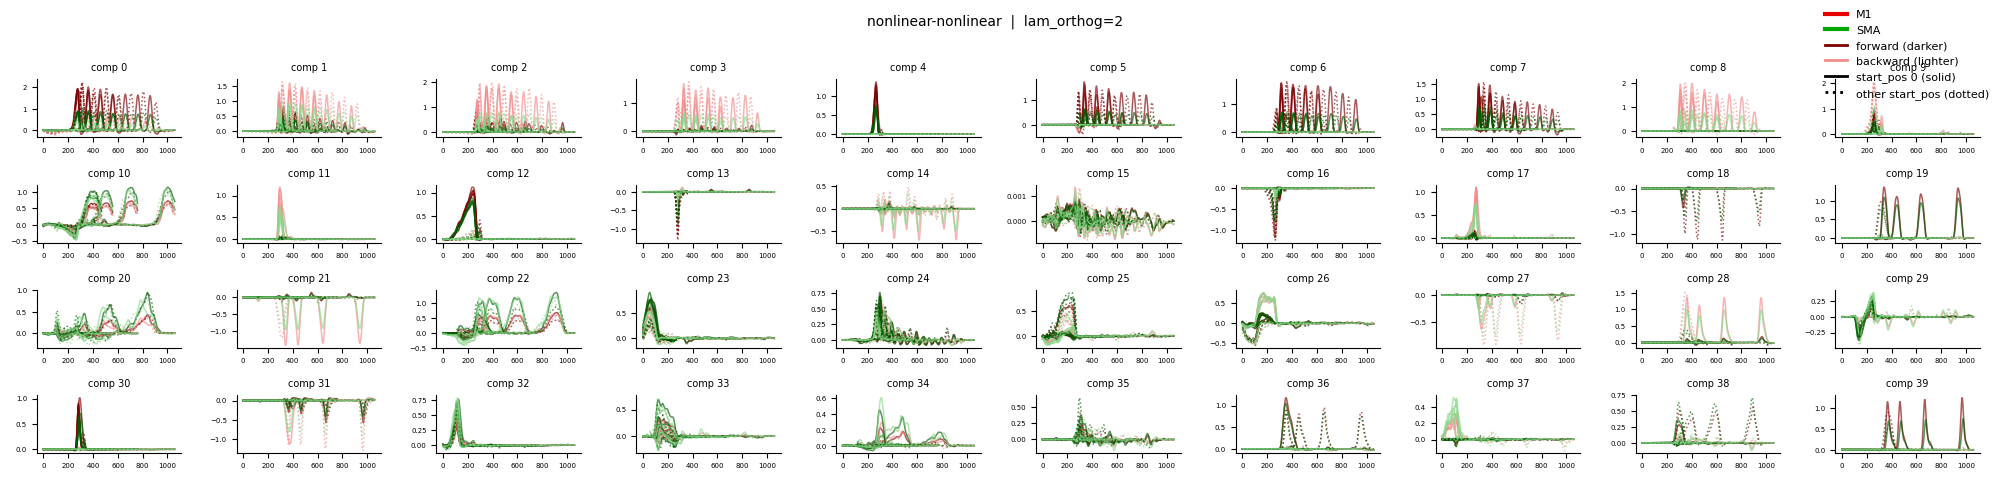

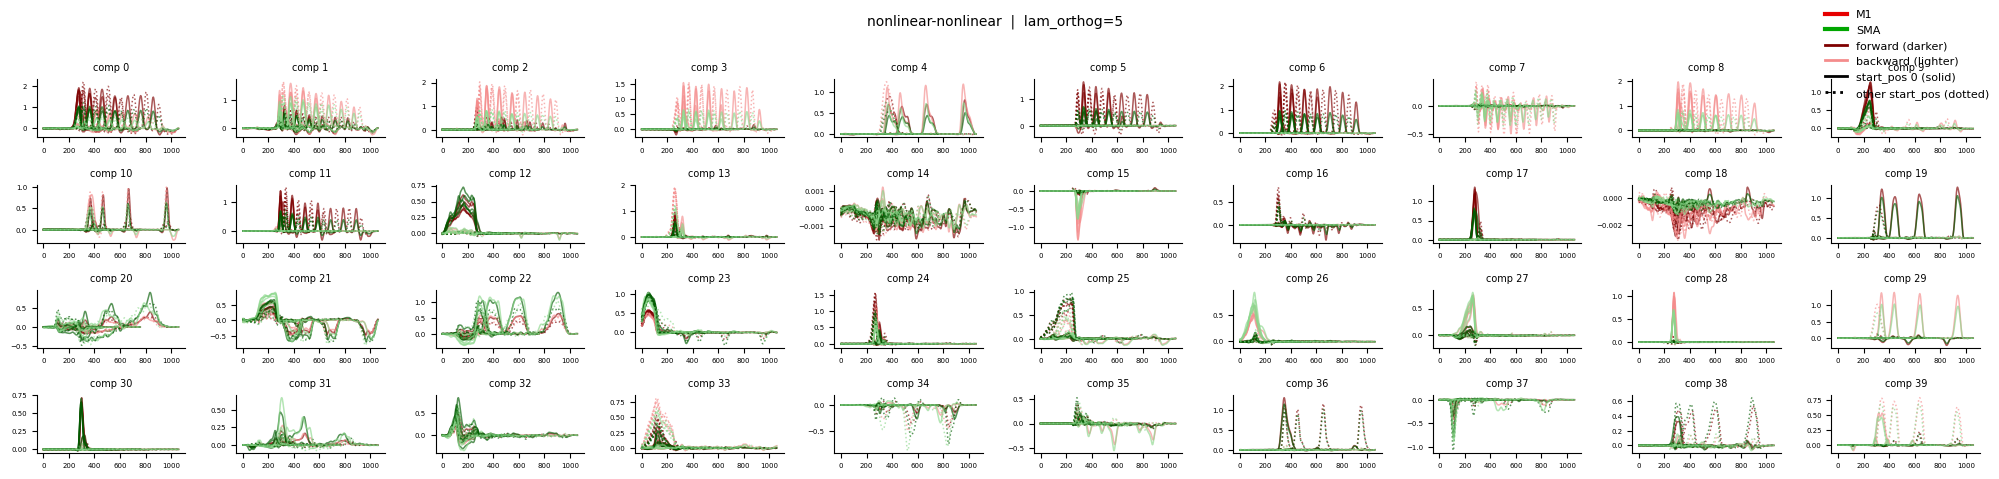

In [25]:
msca = mSCA(n_components=40, n_epochs=5000, loss_func="Gaussian", lr=1e-3, filter_len=41, linear=False, region_weights=None, lam_sparse=None, lam_orthog=None, lam_region=None, batch_size=64, cd_rate=0.5, decoder_type="nonlinear", decoder_hidden_size=40, decoder_activation="GeLU", device="cpu", cd_mode="both", post_hoc_epoch=-1)
msca.load("./results/Drake/nonlinear-nonlinear-sweeping_lam_orthog/msca_nonlinear_nonlinear_lamOrthog_0p0.pt", X)
import torch
import torch._dynamo
import numpy as np
import matplotlib.pyplot as plt

torch._dynamo.config.suppress_errors = True
dataset_spec = {
    "loader": "cycling",
    "files": {"M1": "Drake_interp_cycling_m1_rawRates.mat"},
    # optionally: "data_dir": "data"  (relative to _HERE, or absolute)
}

Z = msca.transform(X)


import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import io
import torch
import sys
sys.path.insert(0, "../..")  # repo root so `msca` is importable
from msca import mSCA
results_dir = Path("results/Drake/nonlinear-nonlinear-sweeping_lam_orthog")

model_files = sorted(
    results_dir.glob("msca_nonlinear_nonlinear_lamOrthog_*.pt"),
    key=lambda p: float(re.search(r"lamOrthog_(.+)\.pt", p.name).group(1).replace("p", "."))
)

for model_path in model_files:
    lam_val = float(re.search(r"lamOrthog_(.+)\.pt", model_path.name).group(1).replace("p", "."))

    checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)
    meta = checkpoint["meta"]

    msca_model = mSCA(
        n_components=meta["n_components"],
        linear=meta["linear"],
        decoder_type=meta["decoder_type"],
        decoder_hidden_size=meta["decoder_hidden_size"],
        decoder_activation=meta["decoder_activation"],
    )
    msca_model.load(str(model_path), X)
    latents = msca_model.transform(X)

    plot_cell(latents,*load_conditions(dataset_spec),title=f"nonlinear-nonlinear  |  lam_orthog={lam_val:g}")
